Dataset Preview:
   Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float6

C:\Users\aysha\AppData\Local\Temp\ipykernel_8868\2560205179.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


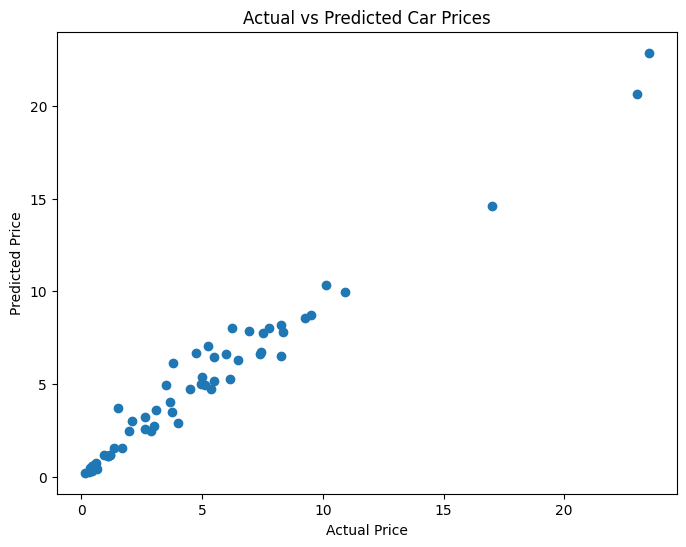


Feature Importance:
Car_Name: 0.0321
Year: 0.0584
Present_Price: 0.8637
Driven_kms: 0.0325
Fuel_Type: 0.0014
Selling_type: 0.0015
Transmission: 0.0093
Owner: 0.0010

Sample Prediction: [3.8885]


In [5]:
# ---------------------------------------
# Car Price Prediction 🚗 (Final Version)
# ---------------------------------------

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------
# 1. Load Dataset
# ------------------------------
df = pd.read_csv("car data.csv")

print("Dataset Preview:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

# ------------------------------
# 2. Data Cleaning
# ------------------------------
df.dropna(inplace=True)

# ------------------------------
# 3. Convert Categorical Columns
# ------------------------------
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# ------------------------------
# 4. Feature & Target Split
# ------------------------------
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# ------------------------------
# 5. Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# 6. Model (Better than Linear Regression)
# ------------------------------
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ------------------------------
# 7. Prediction
# ------------------------------
y_pred = model.predict(X_test)

# ------------------------------
# 8. Evaluation
# ------------------------------
print("\nModel Performance:")
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# ------------------------------
# 9. Visualization
# ------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

# ------------------------------
# 10. Feature Importance
# ------------------------------
importance = model.feature_importances_

print("\nFeature Importance:")
for name, score in zip(X.columns, importance):
    print(f"{name}: {score:.4f}")

# ------------------------------
# 11. Custom Prediction
# ------------------------------
sample = X.iloc[[0]]   # keep as DataFrame
prediction = model.predict(sample)

print("\nSample Prediction:", prediction)